In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/mecaniqa_dataset - mecaniqa_dataset.csv.csv')
display(df.head())

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


In [ ]:
df = pd.read_csv('/content/mecaniqa_dataset - mecaniqa_dataset.csv.csv', parse_dates=['Data'])
df = df.sort_values('Data').reset_index(drop=True)
df = df.set_index('Data')

df = df.asfreq('D')

print(f"Período: {df.index.min().date()} até {df.index.max().date()}")
print(f"Total de dias: {len(df)}")
df.head()

Período: 2024-01-01 até 2025-12-31
Total de dias: 731


,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2024-01-01 to 2025-12-31
Freq: D
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trocas_Oleo       725 non-null    float64
 1   Manutencao_Motor  728 non-null    float64
dtypes: float64(2)
memory usage: 17.1 KB


In [ ]:
df.describe()

,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000


In [ ]:
dias_sem_registro = df.index[df.isna().all(axis=1)]
print(f"Dias completamente sem registro: {len(dias_sem_registro)}")
print("\nValores ausentes por coluna:")
print(df.isna().sum())


Dias completamente sem registro: 0

Valores ausentes por coluna:
Trocas_Oleo         6
Manutencao_Motor    3
dtype: int64


In [ ]:
missing_oleo = df[df['Trocas_Oleo'].isna()]
missing_motor = df[df['Manutencao_Motor'].isna()]

print("Datas com Trocas_Oleo ausente:")
print(missing_oleo.index.tolist())
print("\nDatas com Manutencao_Motor ausente:")
print(missing_motor.index.tolist())

Datas com Trocas_Oleo ausente:
[Timestamp('2024-04-10 00:00:00'), Timestamp('2024-04-11 00:00:00'), Timestamp('2024-04-12 00:00:00'), Timestamp('2024-04-13 00:00:00'), Timestamp('2024-04-14 00:00:00'), Timestamp('2024-04-15 00:00:00')]

Datas com Manutencao_Motor ausente:
[Timestamp('2024-10-27 00:00:00'), Timestamp('2024-10-28 00:00:00'), Timestamp('2024-10-29 00:00:00')]


In [ ]:
df_clean = df.copy()
df_clean[['Trocas_Oleo', 'Manutencao_Motor']] = (
    df_clean[['Trocas_Oleo', 'Manutencao_Motor']].interpolate(method='time')
)

df_clean[['Trocas_Oleo', 'Manutencao_Motor']] = (
    df_clean[['Trocas_Oleo', 'Manutencao_Motor']].ffill().bfill()
)

print("Valores ausentes após tratamento:")
print(df_clean.isna().sum())

Valores ausentes após tratamento:
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64


In [ ]:
def detectar_outliers_iqr(serie, k=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - k * iqr
    limite_sup = q3 + k * iqr
    return (serie < limite_inf) | (serie > limite_sup), limite_inf, limite_sup

outliers_oleo, li_oleo, ls_oleo = detectar_outliers_iqr(df_clean['Trocas_Oleo'])
outliers_motor, li_motor, ls_motor = detectar_outliers_iqr(df_clean['Manutencao_Motor'])

print(f"Trocas_Oleo -> limites válidos: [{li_oleo:.1f}, {ls_oleo:.1f}] | outliers detectados: {outliers_oleo.sum()}")
print(f"Manutencao_Motor -> limites válidos: [{li_motor:.1f}, {ls_motor:.1f}] | outliers detectados: {outliers_motor.sum()}")

print("\nOutliers em Trocas_Oleo:")
print(df_clean.loc[outliers_oleo, 'Trocas_Oleo'])
print("\nOutliers em Manutencao_Motor:")
print(df_clean.loc[outliers_motor, 'Manutencao_Motor'])

Trocas_Oleo -> limites válidos: [-4.5, 55.5] | outliers detectados: 1
Manutencao_Motor -> limites válidos: [-2.0, 22.0] | outliers detectados: 2

Outliers em Trocas_Oleo:
Data
2024-02-15    150.0
Freq: D, Name: Trocas_Oleo, dtype: float64

Outliers em Manutencao_Motor:
Data
2024-07-19    85.0
2025-05-03    24.0
Freq: 288D, Name: Manutencao_Motor, dtype: float64


In [ ]:
utliers_motor = outliers_motor | (df_clean['Manutencao_Motor'] < 0)

def normalizar_outliers(df_in, col, mask_outliers, janela=7):
    serie = df_in[col].copy()
    mediana_movel = serie.rolling(window=janela, center=True, min_periods=1).median()
    serie[mask_outliers] = mediana_movel[mask_outliers]
    return serie

df_clean['Trocas_Oleo'] = normalizar_outliers(df_clean, 'Trocas_Oleo', outliers_oleo)
df_clean['Manutencao_Motor'] = normalizar_outliers(df_clean, 'Manutencao_Motor', outliers_motor)

print("Estatísticas após tratamento de outliers:")
df_clean.describe()

Estatísticas após tratamento de outliers:


,Trocas_Oleo,Manutencao_Motor
count,731.000000,731.000000
mean,25.846785,10.043776
std,10.627107,4.628544
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,53.000000,21.000000


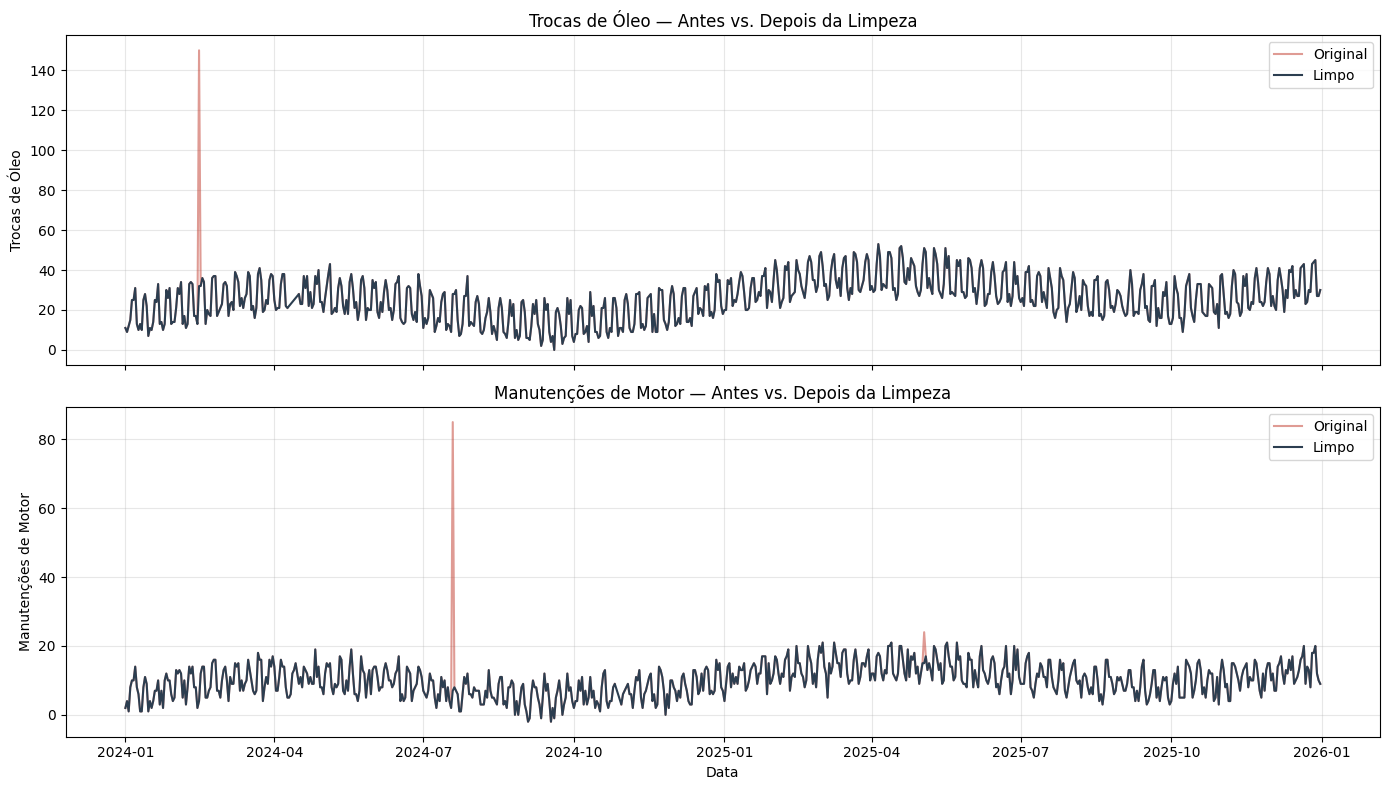

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Trocas_Oleo'], color='#c0392b', alpha=0.5, label='Original')
axes[0].plot(df_clean.index, df_clean['Trocas_Oleo'], color='#2c3e50', label='Limpo')
axes[0].set_title('Trocas de Óleo — Antes vs. Depois da Limpeza')
axes[0].set_ylabel('Trocas de Óleo')
axes[0].legend()

axes[1].plot(df.index, df['Manutencao_Motor'], color='#c0392b', alpha=0.5, label='Original')
axes[1].plot(df_clean.index, df_clean['Manutencao_Motor'], color='#2c3e50', label='Limpo')
axes[1].set_title('Manutenções de Motor — Antes vs. Depois da Limpeza')
axes[1].set_ylabel('Manutenções de Motor')
axes[1].set_xlabel('Data')
axes[1].legend()

plt.tight_layout()
plt.show()

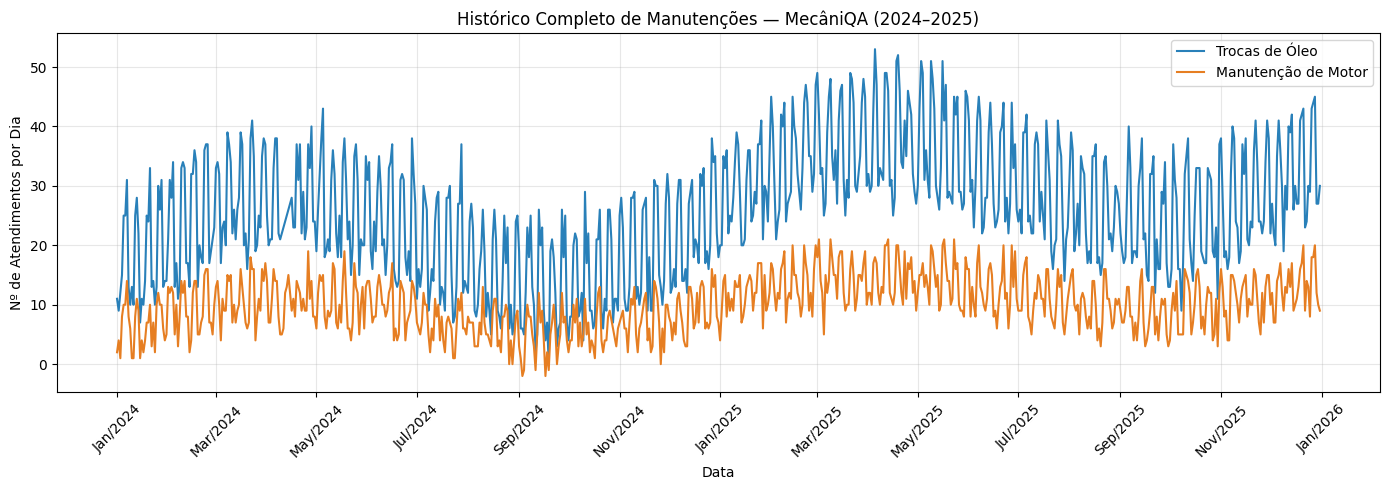

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean.index, df_clean['Trocas_Oleo'], label='Trocas de Óleo', color='#2980b9')
ax.plot(df_clean.index, df_clean['Manutencao_Motor'], label='Manutenção de Motor', color='#e67e22')
ax.set_title('Histórico Completo de Manutenções — MecâniQA (2024–2025)')
ax.set_xlabel('Data')
ax.set_ylabel('Nº de Atendimentos por Dia')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

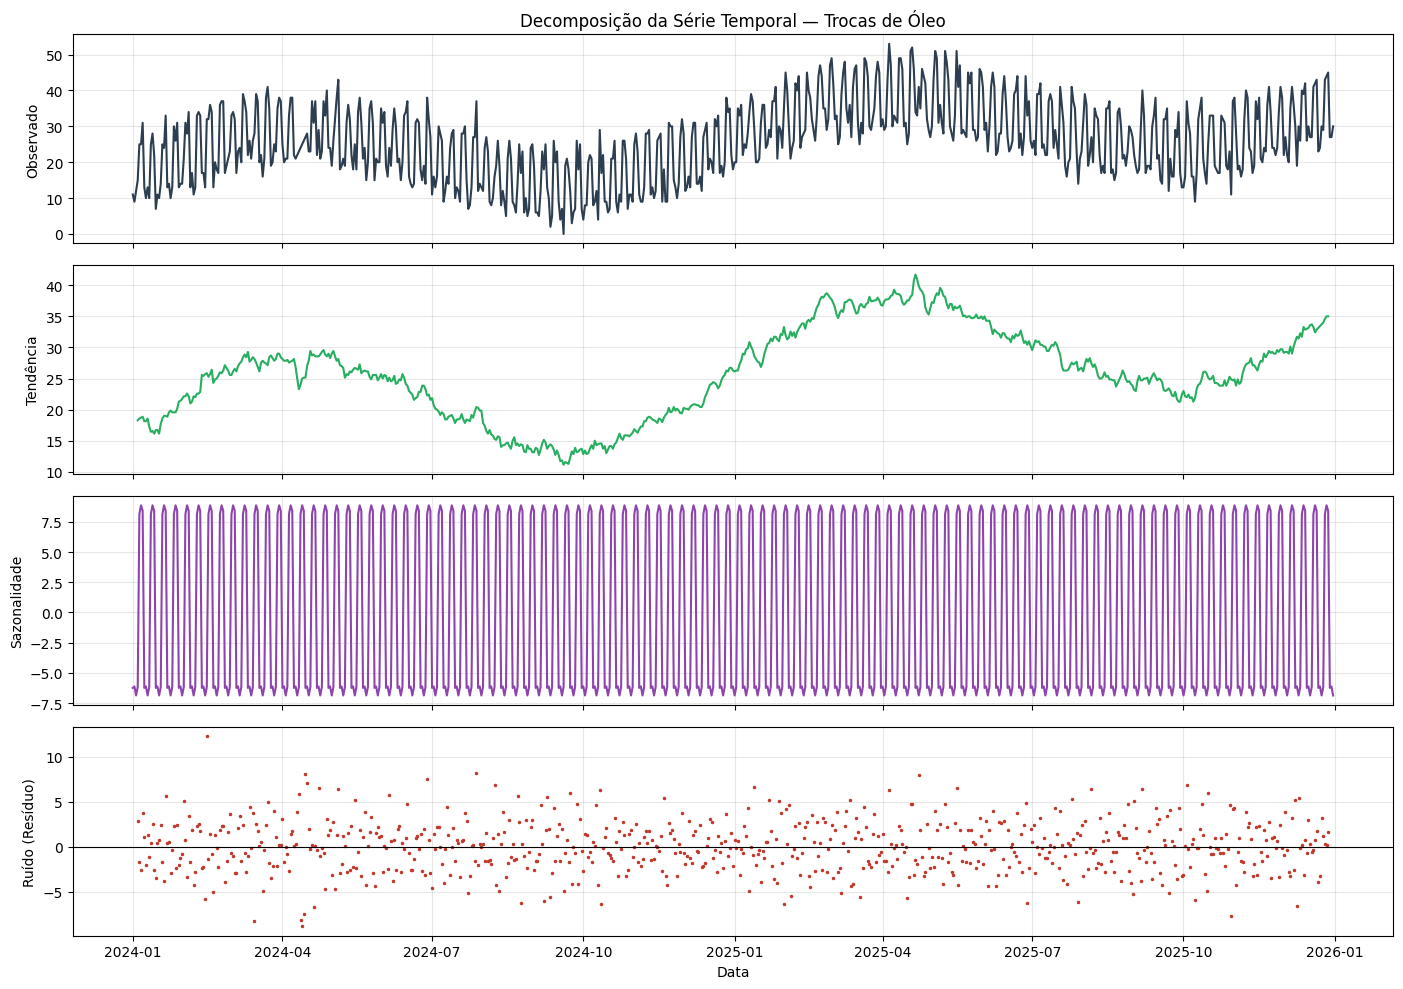

In [ ]:
def plot_decomposicao(serie, titulo, periodo=7):
    resultado = seasonal_decompose(serie, model='additive', period=periodo)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(resultado.observed, color='#2c3e50')
    axes[0].set_ylabel('Observado')
    axes[0].set_title(f'Decomposição da Série Temporal — {titulo}')

    axes[1].plot(resultado.trend, color='#27ae60')
    axes[1].set_ylabel('Tendência')

    axes[2].plot(resultado.seasonal, color='#8e44ad')
    axes[2].set_ylabel('Sazonalidade')

    axes[3].plot(resultado.resid, color='#c0392b', marker='.', linestyle='None', markersize=3)
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].set_ylabel('Ruído (Resíduo)')
    axes[3].set_xlabel('Data')

    plt.tight_layout()
    plt.show()
    return resultado

resultado_oleo = plot_decomposicao(df_clean['Trocas_Oleo'], 'Trocas de Óleo')

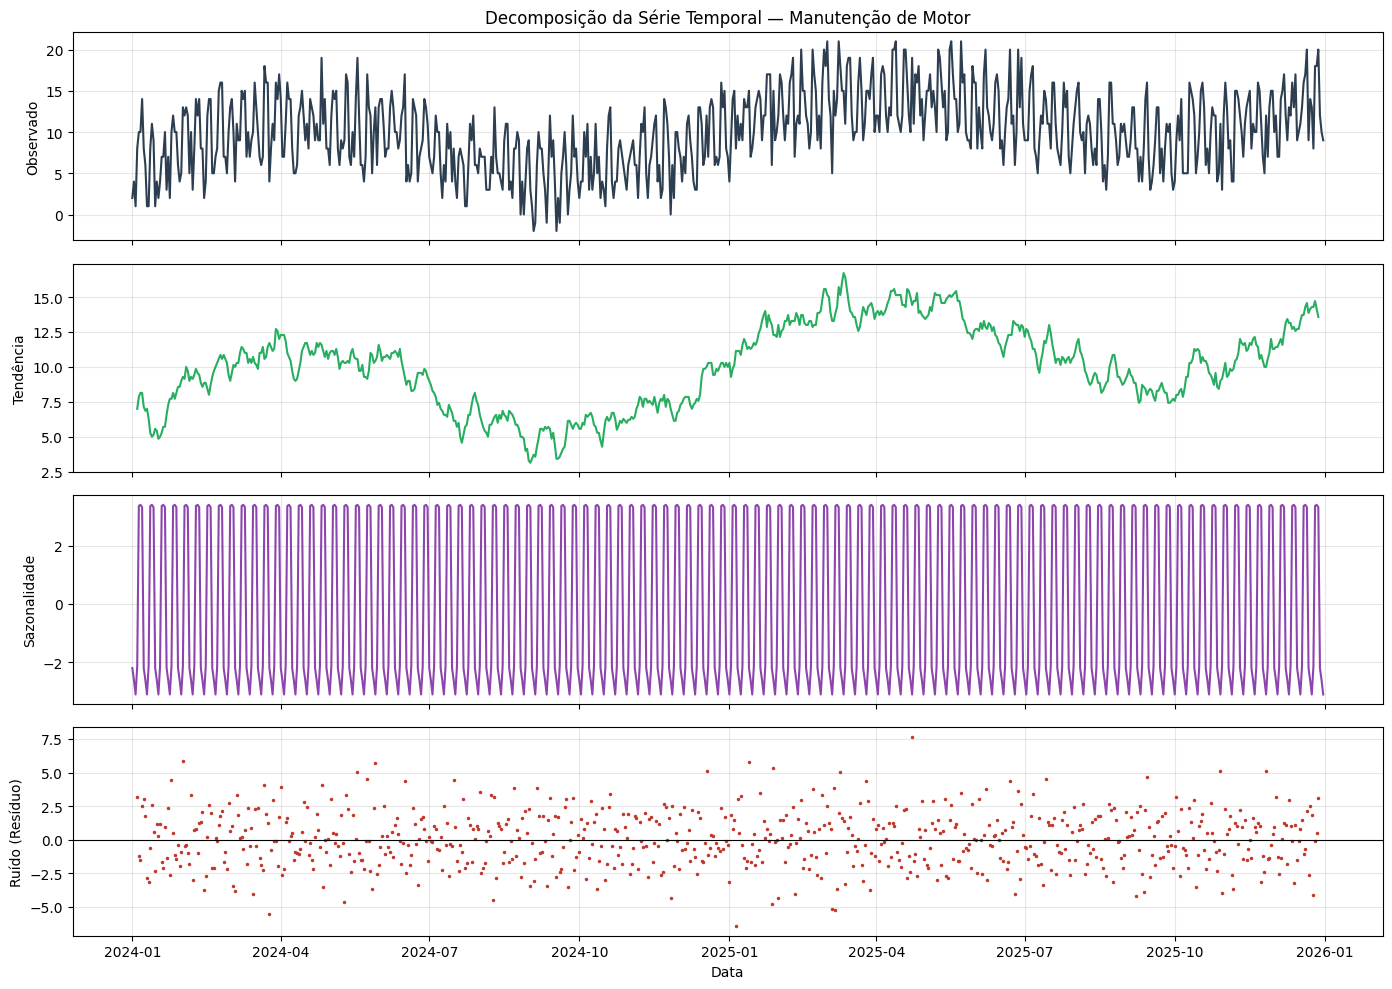

In [ ]:
resultado_motor = plot_decomposicao(df_clean['Manutencao_Motor'], 'Manutenção de Motor')

In [ ]:
def modelo_naive(serie):
    return serie.shift(1)

df_clean['Naive_Oleo'] = modelo_naive(df_clean['Trocas_Oleo'])
df_clean['Naive_Motor'] = modelo_naive(df_clean['Manutencao_Motor'])

df_clean[['Trocas_Oleo', 'Naive_Oleo']].head(10)

,Trocas_Oleo,Naive_Oleo
Data,,
2024-01-01,11.0,NaN
2024-01-02,9.0,11.0
2024-01-03,12.0,9.0
2024-01-04,15.0,12.0
2024-01-05,25.0,15.0
2024-01-06,25.0,25.0
2024-01-07,31.0,25.0
2024-01-08,13.0,31.0
2024-01-09,10.0,13.0


In [ ]:
def modelo_media_movel(serie, janela):
    # shift(1) garante que a previsão de um dia usa apenas dados até o dia anterior (sem vazamento de dados)
    return serie.shift(1).rolling(window=janela).mean()

for col, nome in [('Trocas_Oleo', 'Oleo'), ('Manutencao_Motor', 'Motor')]:
    df_clean[f'MM7_{nome}'] = modelo_media_movel(df_clean[col], 7)
    df_clean[f'MM30_{nome}'] = modelo_media_movel(df_clean[col], 30)

df_clean[['Trocas_Oleo', 'Naive_Oleo', 'MM7_Oleo', 'MM30_Oleo']].tail(10)

,Trocas_Oleo,Naive_Oleo,MM7_Oleo,MM30_Oleo
Data,,,,
2025-12-22,23.0,43.0,33.714286,31.566667
2025-12-23,24.0,23.0,33.285714,30.966667
2025-12-24,30.0,24.0,32.428571,30.633333
2025-12-25,29.0,30.0,32.857143,30.833333
2025-12-26,43.0,29.0,33.142857,31.000000
2025-12-27,44.0,43.0,33.428571,31.700000
2025-12-28,45.0,44.0,33.714286,32.366667
2025-12-29,27.0,45.0,34.000000,32.733333
2025-12-30,27.0,27.0,34.571429,32.266667


In [ ]:
def avaliar(y_real, y_pred):
    df_aval = pd.DataFrame({'real': y_real, 'pred': y_pred}).dropna()
    mae = (df_aval['real'] - df_aval['pred']).abs().mean()
    rmse = np.sqrt(((df_aval['real'] - df_aval['pred']) ** 2).mean())
    return mae, rmse

resultados = []
for col, nome in [('Trocas_Oleo', 'Trocas de Óleo'), ('Manutencao_Motor', 'Manutenção de Motor')]:
    for modelo in ['Naive', 'MM7', 'MM30']:
        chave = f"{modelo}_{'Oleo' if col == 'Trocas_Oleo' else 'Motor'}"
        mae, rmse = avaliar(df_clean[col], df_clean[chave])
        resultados.append({'Série': nome, 'Modelo': modelo, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})

df_resultados = pd.DataFrame(resultados)
df_resultados

,Série,Modelo,MAE,RMSE
0,Trocas de Óleo,Naive,6.59,8.89
1,Trocas de Óleo,MM7,7.34,8.07
2,Trocas de Óleo,MM30,7.28,8.14
3,Manutenção de Motor,Naive,3.35,4.29
4,Manutenção de Motor,MM7,3.22,3.79
5,Manutenção de Motor,MM30,3.18,3.77


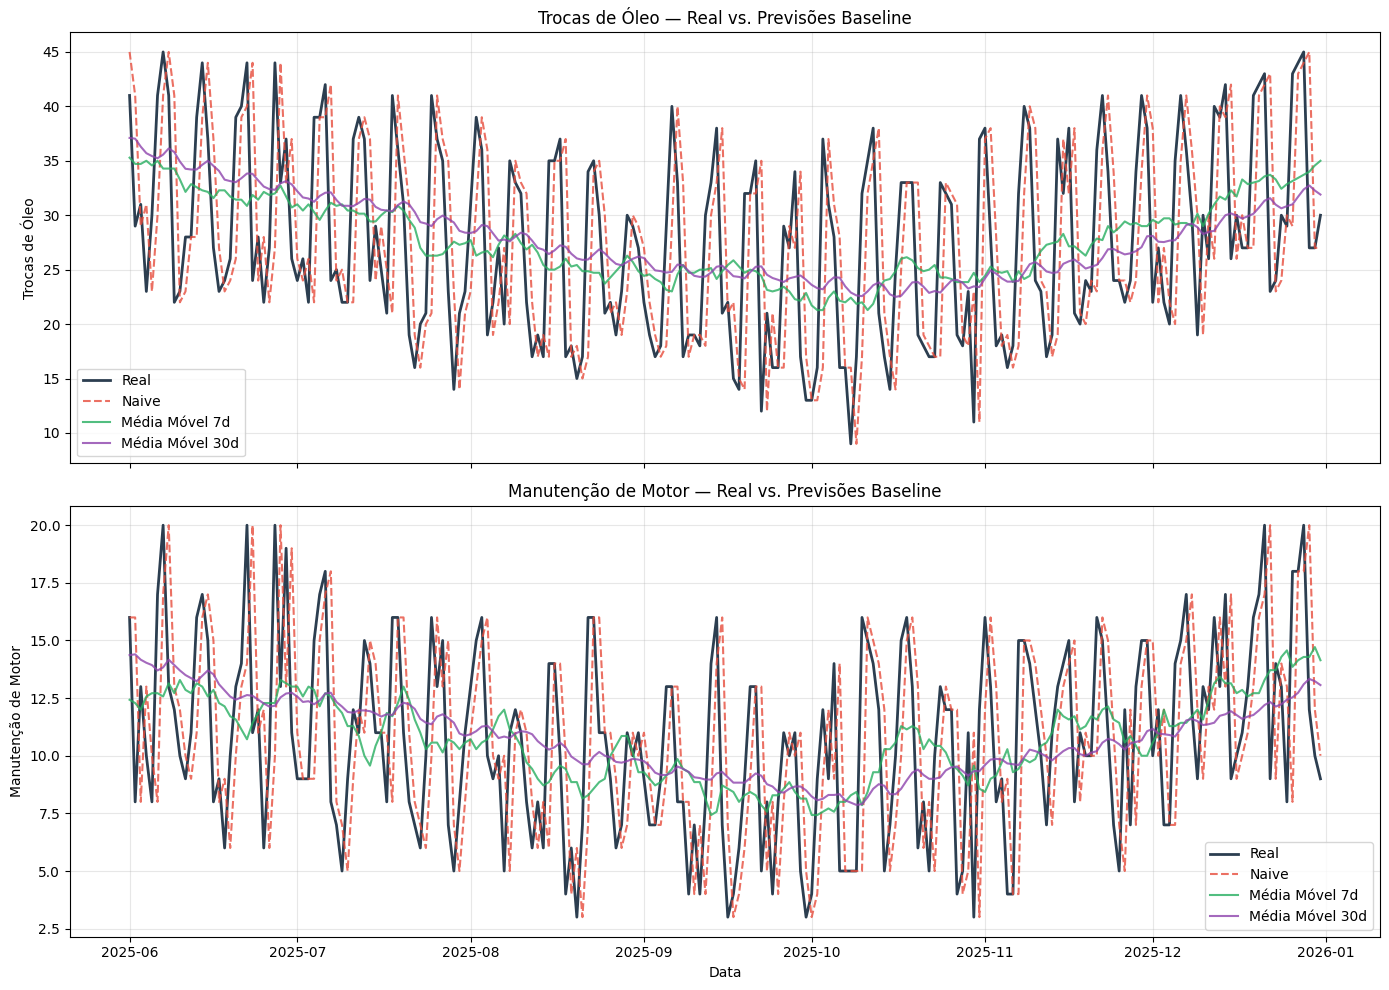

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

janela_plot = df_clean.index >= '2025-06-01'  # últimos meses, para melhor legibilidade visual

axes[0].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'Trocas_Oleo'], label='Real', color='#2c3e50', linewidth=2)
axes[0].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'Naive_Oleo'], label='Naive', color='#e74c3c', alpha=0.8, linestyle='--')
axes[0].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'MM7_Oleo'], label='Média Móvel 7d', color='#27ae60', alpha=0.8)
axes[0].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'MM30_Oleo'], label='Média Móvel 30d', color='#8e44ad', alpha=0.8)
axes[0].set_title('Trocas de Óleo — Real vs. Previsões Baseline')
axes[0].set_ylabel('Trocas de Óleo')
axes[0].legend()

axes[1].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'Manutencao_Motor'], label='Real', color='#2c3e50', linewidth=2)
axes[1].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'Naive_Motor'], label='Naive', color='#e74c3c', alpha=0.8, linestyle='--')
axes[1].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'MM7_Motor'], label='Média Móvel 7d', color='#27ae60', alpha=0.8)
axes[1].plot(df_clean.index[janela_plot], df_clean.loc[janela_plot, 'MM30_Motor'], label='Média Móvel 30d', color='#8e44ad', alpha=0.8)
axes[1].set_title('Manutenção de Motor — Real vs. Previsões Baseline')
axes[1].set_ylabel('Manutenção de Motor')
axes[1].set_xlabel('Data')
axes[1].legend()

plt.tight_layout()
plt.show()
